In [1]:
# MİNİ PROJE: Modern CNN Mimarilerinde Çıkarım (Inference) Karşılaştırması
#**Amaç:** Bu projede, derin ve yüksek parametreli bir model olan **VGG16** ile donanım dostu, mobil odaklı **MobileNetV2**
#modellerinin hız (saniye) ve doğruluk oranları karşılaştırılacaktır. 
#İki model de ImageNet veri seti ile önceden eğitilmiş (Pre-trained) ağırlıklara sahiptir.
 #   Test için standart bir kedi fotoğrafı kullanılacaktır.

In [2]:
# 1. Gerekli Kütüphanelerin Yüklenmesi
import tensorflow as tf
from tensorflow.keras.applications import vgg16, mobilenet_v2
from tensorflow.keras.preprocessing import image
import numpy as np
import time
import matplotlib.pyplot as plt

print("Kütüphane yüklendi. TensorFlow Sürümü:", tf.__version__)

Kütüphane yüklendi. TensorFlow Sürümü: 2.21.0


In [3]:
### 2. Önceden Eğitilmiş (Pre-trained) Modellerin Yüklenmesi
#Bu aşamada ImageNet ağırlıkları ile eğitilmiş VGG16 ve MobileNetV2 modellerini belleğe alıyoruz. 
# VGG16
# MobileNetV2
# Modelleri internetten indirip belleğe alıyoruz
print("VGG16 Yükleniyor...")
model_vgg = vgg16.VGG16(weights='imagenet')

print("MobileNetV2 Yükleniyor...")
model_mobilenet = mobilenet_v2.MobileNetV2(weights='imagenet')

print("Modeller başarıyla yüklendi!")

VGG16 Yükleniyor...
MobileNetV2 Yükleniyor...
Modeller başarıyla yüklendi!


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import time

# TAHMİN VE ANALİZ FONKSİYONU
def predict_and_evaluate(model, target_size, preprocess_function, decode_function, model_name, path_to_img):
    # Fonksiyon artık dışarıdan gelen 'path_to_img' parametresini kullanıyor
    img = image.load_img(path_to_img, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    # Ön ayar (Preprocessing) burada yapılıyor
    img_array = preprocess_function(img_array)
    
    start_time = time.time()
    predictions = model.predict(img_array, verbose=0) # verbose=0 çıktı kirliliğini engeller
    end_time = time.time()
    
    decoded_preds = decode_function(predictions, top=1)[0][0]
    
    return {
        "Model": model_name,
        "Tahmin": decoded_preds[1],
        "Güven Skoru": f"%{decoded_preds[2]*100:.2f}",
        "Süre (Saniye)": f"{end_time - start_time:.4f}"
    }

In [5]:
import pandas as pd # Verileri tablo yapmak için

# 1. TEST EDİLECEK RESİMLERİN LİSTESİ
# İstediğin kadar resim ekleyebilirsin, sadece yollarını (path) tırnak içinde araya virgül koyarak yaz.
resimler = [
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kedi.jpg",
    r"C:\Users\LENOVO\makine_ogrenmesi\kedi2.jpg",
    r"C:\Users\LENOVO\makine_ogrenmesi\kopek.jpg",
    r"C:\Users\LENOVO\makine_ogrenmesi\kedi3.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kus1.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kus2.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kus3.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kus4.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kus5.jpeg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kus6.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kus7.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kus8.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kus10.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kus9.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kedi4.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kedi5.jpeg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kedi6.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kedi7.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kedi8.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kedi9.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kedi10.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kopek2.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kopek3.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kopek4.jpeg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kopek5.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kopek6.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kopek7.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kopek8.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kopek9.jpg",
    r"C:\Users\LENOVO\Makine_Ogrenmesi\kopek10.jpg",# Varsa başka resimler...
]

tum_veriler = []

print("Deney başlatıldı. Resimler analiz ediliyor...")

for r_yolu in resimler:
    d_adi = r_yolu.split("\\")[-1] # Tabloda güzel durması için dosya adını alıyoruz
    
    # VGG16 Analizi
    res_vgg = predict_and_evaluate(model_vgg, (224,224), vgg16.preprocess_input, vgg16.decode_predictions, "VGG16", r_yolu)
    res_vgg['Görsel'] = d_adi
    tum_veriler.append(res_vgg)
    
    # MobileNetV2 Analizi
    res_mnet = predict_and_evaluate(model_mobilenet, (224,224), mobilenet_v2.preprocess_input, mobilenet_v2.decode_predictions, "MobileNetV2", r_yolu)
    res_mnet['Görsel'] = d_adi
    tum_veriler.append(res_mnet)

# Tabloyu oluştur ve göster
df = pd.DataFrame(tum_veriler)
df = df[['Görsel', 'Model', 'Tahmin', 'Güven Skoru', 'Süre (Saniye)']] # Sütunları düzenle

print("\n" + "="*80)
print("MODERN CNN MİMARİLERİ KARŞILAŞTIRMALI ANALİZ TABLOSU")
print("="*80)
print(df.to_string(index=False))
print("="*80)

Deney başlatıldı. Resimler analiz ediliyor...

MODERN CNN MİMARİLERİ KARŞILAŞTIRMALI ANALİZ TABLOSU
     Görsel       Model                         Tahmin Güven Skoru Süre (Saniye)
   kedi.jpg       VGG16                          tabby      %55.84        1.5470
   kedi.jpg MobileNetV2                          tabby      %69.10        3.9736
  kedi2.jpg       VGG16                   Egyptian_cat       %8.39        0.8082
  kedi2.jpg MobileNetV2                   Egyptian_cat      %28.45        0.3335
  kopek.jpg       VGG16                           chow      %71.67        0.7483
  kopek.jpg MobileNetV2                     Pomeranian      %83.52        0.2671
  kedi3.jpg       VGG16                   Egyptian_cat      %53.00        0.7660
  kedi3.jpg MobileNetV2                   Egyptian_cat      %48.17        0.2957
   kus1.jpg       VGG16                   African_grey      %93.40        0.8870
   kus1.jpg MobileNetV2                   African_grey      %83.15        0.3182
   kus2.j

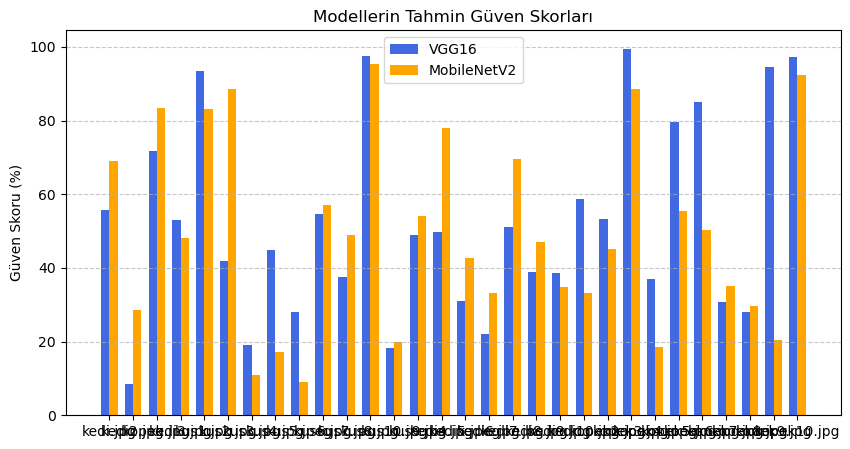

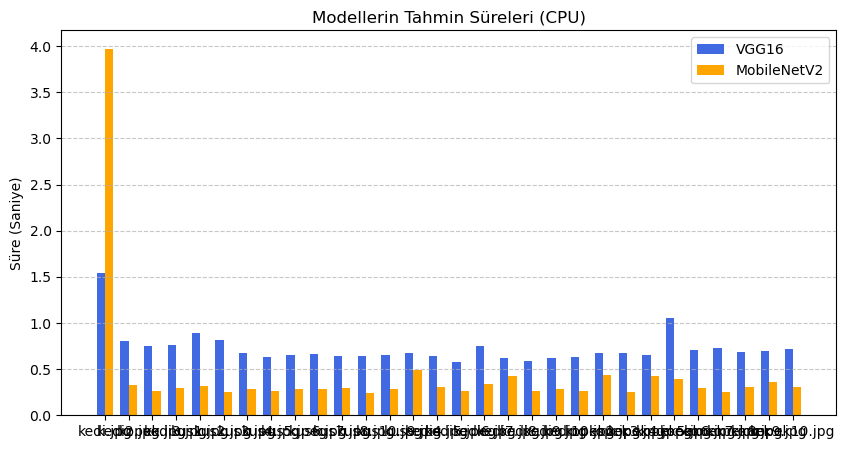

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. VERİLERİ GRAFİK İÇİN HAZIRLAMA (Sayısal formata çevirme)
df_plot = df.copy()
# "%55.84" gibi metinleri grafikte çizmek için 55.84 gibi sayılara çeviriyoruz
df_plot['Güven Sayısal'] = df_plot['Güven Skoru'].str.replace('%', '').astype(float)
df_plot['Süre Sayısal'] = df_plot['Süre (Saniye)'].astype(float)

gorseller = df_plot['Görsel'].unique()
x = np.arange(len(gorseller))  # Görsel etiketlerinin yerleri
genislik = 0.35  # Çubukların genişliği

# 2. GRAFİK: GÜVEN SKORU KARŞILAŞTIRMASI
plt.figure(figsize=(10, 5))
vgg_guven = df_plot[df_plot['Model'] == 'VGG16']['Güven Sayısal']
mnet_guven = df_plot[df_plot['Model'] == 'MobileNetV2']['Güven Sayısal']

plt.bar(x - genislik/2, vgg_guven, genislik, label='VGG16', color='royalblue')
plt.bar(x + genislik/2, mnet_guven, genislik, label='MobileNetV2', color='orange')

plt.ylabel('Güven Skoru (%)')
plt.title('Modellerin Tahmin Güven Skorları')
plt.xticks(x, gorseller)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. GRAFİK: SÜRE KARŞILAŞTIRMASI
plt.figure(figsize=(10, 5))
vgg_sure = df_plot[df_plot['Model'] == 'VGG16']['Süre Sayısal']
mnet_sure = df_plot[df_plot['Model'] == 'MobileNetV2']['Süre Sayısal']

plt.bar(x - genislik/2, vgg_sure, genislik, label='VGG16', color='royalblue')
plt.bar(x + genislik/2, mnet_sure, genislik, label='MobileNetV2', color='orange')

plt.ylabel('Süre (Saniye)')
plt.title('Modellerin Tahmin Süreleri (CPU)')
plt.xticks(x, gorseller)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()